In [2]:
#CNN SD implementation for NG - CIP dataset
import numpy as np
import pandas as pd
from Bio import SeqIO
import torch
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from torchinfo import summary
import os

In [3]:
GENOME_SIZE = 2171755 #NG

In [4]:
# load pheno df
pheno_df = pd.read_csv("NeisseriaGono-CIP.tsv", sep="\t")
print(pheno_df.head())

              id drug_agent pheno_eucast
1  ECDC_BE18_497        CIP            S
2    ERR11171225        CIP            R
3    ERR11171451        CIP            R
4    ERR11171618        CIP            R
5    ERR11171778        CIP            S


In [16]:
pheno_df["pheno_eucast"].value_counts()

pheno_eucast
R    11
S     8
Name: count, dtype: int64

In [5]:
# parse 19 samples from vcf folder from pheno df
accessions = pheno_df["id"].tolist()
vcf_path = "Neisseria_gonorrhoeae"
#  extract accession from vcf file name : ERR11171225_output.vcf to ERR11171225
vcf_files = [f for f in os.listdir(vcf_path) if f.endswith(".vcf")]
vcf_accessions = [f.split("_")[0] for f in vcf_files]

# filter pheno df to only include samples with vcf files
pheno_df = pheno_df[pheno_df["id"].isin(vcf_accessions)]
print(pheno_df.head())
print(pheno_df.shape)

            id drug_agent pheno_eucast
2  ERR11171225        CIP            R
3  ERR11171451        CIP            R
4  ERR11171618        CIP            R
5  ERR11171778        CIP            S
6  ERR11171779        CIP            R
(19, 3)


In [6]:
# load data
X = np.load("X_dataset.npy")   # expected shape: (N, 6, L)

pheno_df["pheno_encoded"] = pheno_df["pheno_eucast"].apply(lambda x: 1 if x == "R" else 0)
y = pheno_df["pheno_encoded"].values  # expected shape: (N,)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

assert X.shape[0] == len(y), f"Mismatch: X has {X.shape[0]} samples but y has {len(y)} labels"
assert X.ndim == 3, f"Expected X to have shape (N, 6, L), got {X.shape}"
assert X.shape[1] == 6, f"Expected 6 channels, got {X.shape[1]}"

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)   # BCEWithLogitsLoss expects float targets

print("Torch X shape:", X.shape)
print("Torch y shape:", y.shape)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X = X.to(device)
y = y.to(device)

Shape of X: (19, 6, 2171755)
Shape of y: (19,)
Torch X shape: torch.Size([19, 6, 2171755])
Torch y shape: torch.Size([19])


In [ ]:
import torch
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()

        self.conv1 = nn.Conv1d(6, 16, kernel_size=12, stride=4)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=12, stride=4)
        self.pool1 = nn.MaxPool1d(kernel_size=4, stride=4)

        self.conv3 = nn.Conv1d(32, 32, kernel_size=3, stride=2)
        self.pool2 = nn.MaxPool1d(kernel_size=4, stride=4)

        self.global_pool = nn.AdaptiveMaxPool1d(1)

        self.fc1 = nn.Linear(32, 64)
        self.out = nn.Linear(64, num_classes)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = self.pool1(x)
        x = torch.relu(self.conv3(x))
        x = self.pool2(x)
        x = self.global_pool(x).squeeze(-1)
        x = torch.relu(self.fc1(x))
        x = self.out(x)
        return x

In [10]:
#instantiate model
model = CNN(num_classes=1)
model = model.to(device="cuda" if torch.cuda.is_available() else "cpu")
summary(model)

Layer (type:depth-idx)                   Param #
CNN                                      --
├─Conv1d: 1-1                            1,168
├─Conv1d: 1-2                            6,176
├─MaxPool1d: 1-3                         --
├─Conv1d: 1-4                            3,104
├─MaxPool1d: 1-5                         --
├─AdaptiveMaxPool1d: 1-6                 --
├─Linear: 1-7                            2,112
├─Linear: 1-8                            65
Total params: 12,625
Trainable params: 12,625
Non-trainable params: 0

In [ ]:
# split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shapes:", X_train.shape, y_train.shape)
print("Test shapes:", X_test.shape, y_test.shape)

In [ ]:
# no split test pass
# pass X, y

input_length = X.shape[2]
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

#train
num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    outputs = model(X)              # shape: (N, 1)
    outputs = outputs.squeeze(1)    # shape: (N,)

    loss = criterion(outputs, y)

    loss.backward()
    optimizer.step()

    with torch.no_grad():
        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).float()
        acc = (preds == y).float().mean()

    print(f"Epoch {epoch+1:02d} | Loss: {loss.item():.4f} | Acc: {acc.item():.4f}")

Epoch 01 | Loss: 0.6949 | Acc: 0.4211
Epoch 02 | Loss: 0.6916 | Acc: 0.5789
Epoch 03 | Loss: 0.6889 | Acc: 0.5789
Epoch 04 | Loss: 0.6866 | Acc: 0.5789
Epoch 05 | Loss: 0.6847 | Acc: 0.5789
Epoch 06 | Loss: 0.6829 | Acc: 0.5789
Epoch 07 | Loss: 0.6818 | Acc: 0.5789
Epoch 08 | Loss: 0.6809 | Acc: 0.5789
Epoch 09 | Loss: 0.6802 | Acc: 0.5789
Epoch 10 | Loss: 0.6798 | Acc: 0.5789


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, average_precision_score

model.eval()

with torch.no_grad():
    logits = model(X_test).squeeze(1)
    probs = torch.sigmoid(logits)

    # move to CPU numpy
    probs_np = probs.cpu().numpy()
    y_np = y_test.cpu().numpy()

    # binary predictions
    preds_np = (probs_np > 0.5).astype(int)

acc = accuracy_score(y_np, preds_np)

precision = precision_score(y_np, preds_np, pos_label=1, zero_division=0)
recall = recall_score(y_np, preds_np, pos_label=1, zero_division=0)

# AUROC requires both classes present
try:
    auroc = roc_auc_score(y_np, probs_np)
except ValueError:
    auroc = float("nan")

# AUPRC
auprc = average_precision_score(y_np, probs_np)

print(f"Accuracy : {acc:.4f}")
print(f"Precision (R): {precision:.4f}")
print(f"Recall (R)   : {recall:.4f}")
print(f"AUROC        : {auroc:.4f}")
print(f"AUPRC        : {auprc:.4f}")

Accuracy : 0.5789
Precision (R): 0.5789
Recall (R)   : 1.0000
AUROC        : 0.8750
AUPRC        : 0.9096


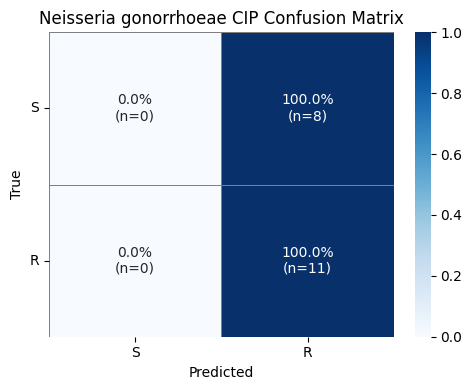

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_np, preds_np)

labels = ["S", "R"]  # 0 = S, 1 = R

cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True)

annot = np.empty_like(cm).astype(str)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        pct = cm_percent[i, j] * 100
        count = cm[i, j]
        annot[i, j] = f"{pct:.1f}%\n(n={count})"

cm_df = pd.DataFrame(cm_percent, index=labels, columns=labels)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_df,
    annot=annot,
    fmt="",
    cmap="Blues",
    cbar=True,
    vmin=0,
    vmax=1,
    linewidths=0.5,
    linecolor="gray"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Neisseria gonorrhoeae CIP Confusion Matrix")
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()
plt.savefig("confusion_matrix.png", dpi=300)